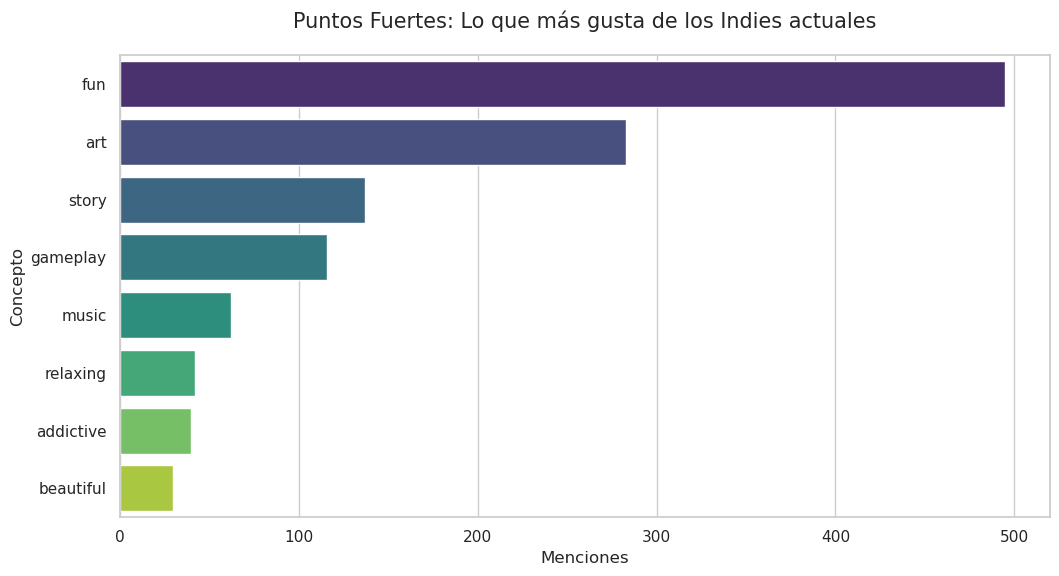

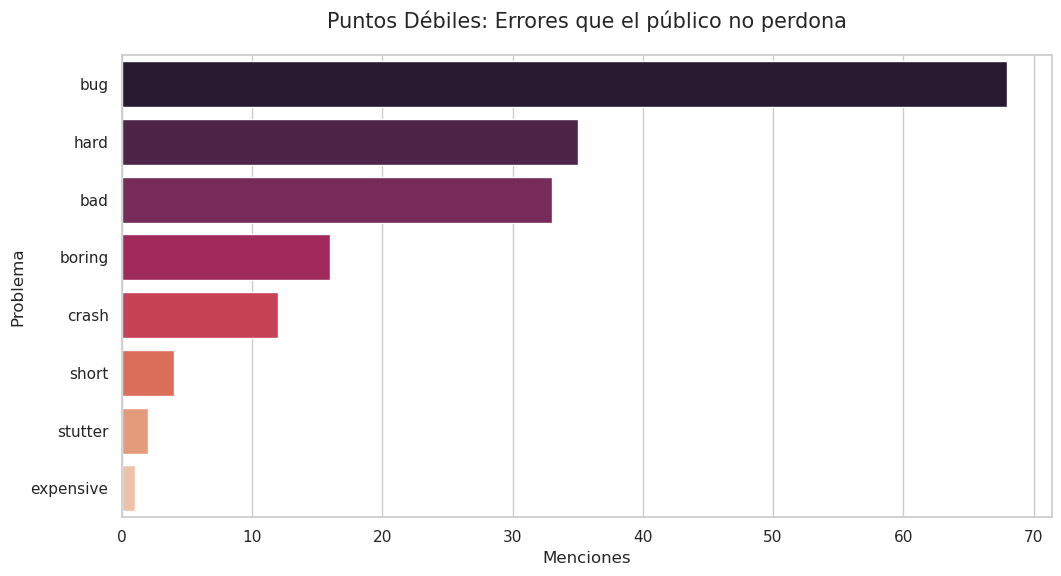

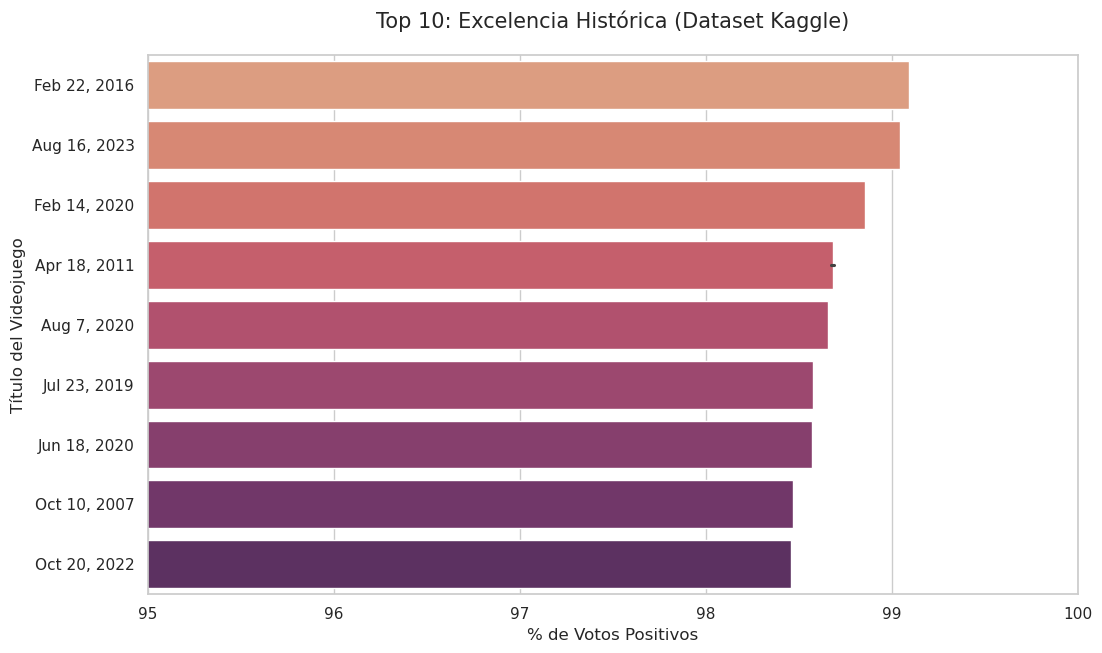

⚠️ No hay datos de precio para graficar. Revisa el CSV.


<Figure size 1200x500 with 0 Axes>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import re

# 1. Configuración de Estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# 2. Conexión a MongoDB
client = MongoClient('mongodb://mongodb:27017')
db = client['steam_db']

# Cargar Datos
df_rev = pd.DataFrame(list(db.reviews_raw.find()))
df_hist = pd.DataFrame(list(db.juegos_historicos.find()))

# --- LIMPIEZA AGRESIVA (DATA WRANGLING) ---

# Limpiar Precios: Quitamos cualquier cosa que no sea número o punto
def limpiar_precio_pro(valor):
    if pd.isna(valor): return 0.0
    texto = str(valor).replace(',', '.')
    solo_numeros = re.findall(r'\d+\.\d+|\d+', texto)
    return float(solo_numeros[0]) if solo_numeros else 0.0

df_hist['Price'] = df_hist['Price'].apply(limpiar_precio_pro)

# Limpiar Nombres y Fechas
df_hist['Name'] = df_hist['Name'].astype(str).str.strip()
df_hist['Release date'] = pd.to_datetime(df_hist['Release date'], errors='coerce')
df_hist['Year'] = df_hist['Release date'].dt.year

# Limpiar Votos
df_hist['Positive'] = pd.to_numeric(df_hist['Positive'], errors='coerce').fillna(0)
df_hist['Negative'] = pd.to_numeric(df_hist['Negative'], errors='coerce').fillna(0)

# =========================================================
# GRÁFICA 1: ¿Qué VALORAN más los jugadores? (Scraping)
# =========================================================
plt.figure(figsize=(12, 6))
df_pos = df_rev[df_rev['voted_up'] == True]
keywords_pos = ['fun', 'art', 'music', 'story', 'gameplay', 'relaxing', 'beautiful', 'addictive']
conteo_pos = {p: df_pos['review'].str.contains(p, case=False).sum() for p in keywords_pos}
df_plot_pos = pd.DataFrame(list(conteo_pos.items()), columns=['Concepto', 'Menciones']).sort_values('Menciones', ascending=False)

sns.barplot(data=df_plot_pos, x='Menciones', y='Concepto', hue='Concepto', palette='viridis', legend=False)
plt.title('Puntos Fuertes: Lo que más gusta de los Indies actuales', fontsize=15, pad=20)
plt.show()

# =========================================================
# GRÁFICA 2: ¿Qué PENALIZAN más los jugadores? (Scraping)
# =========================================================
plt.figure(figsize=(12, 6))
df_neg = df_rev[df_rev['voted_up'] == False]
keywords_neg = ['bug', 'bad', 'crash', 'boring', 'expensive', 'short', 'hard', 'stutter']
conteo_neg = {p: df_neg['review'].str.contains(p, case=False).sum() for p in keywords_neg}
df_plot_neg = pd.DataFrame(list(conteo_neg.items()), columns=['Problema', 'Menciones']).sort_values('Menciones', ascending=False)

sns.barplot(data=df_plot_neg, x='Menciones', y='Problema', hue='Problema', palette='rocket', legend=False)
plt.title('Puntos Débiles: Errores que el público no perdona', fontsize=15, pad=20)
plt.show()

# =========================================================
# GRÁFICA 3: Top 10 Juegos más amados (Kaggle) - ¡CORREGIDA!
# =========================================================
plt.figure(figsize=(12, 7))
# Calculamos Ratio y evitamos división por cero
df_hist['Total_Votos'] = df_hist['Positive'] + df_hist['Negative']
df_hist['Ratio'] = (df_hist['Positive'] / df_hist['Total_Votos']) * 100
# Filtramos por juegos con muchos votos para que los nombres sean reales y famosos
df_top = df_hist[df_hist['Total_Votos'] > 20000].sort_values('Ratio', ascending=False).head(10).copy()

# Forzamos a que el eje Y use la columna 'Name' y reiniciamos el índice
df_top = df_top.reset_index(drop=True)

sns.barplot(data=df_top, x='Ratio', y='Name', hue='Name', palette='flare', legend=False)
plt.xlim(95, 100) # Zoom para ver diferencias
plt.title('Top 10: Excelencia Histórica (Dataset Kaggle)', fontsize=15, pad=20)
plt.xlabel('% de Votos Positivos')
plt.ylabel('Título del Videojuego')
plt.show()

# =========================================================
# GRÁFICA 4: Evolución de Precios (2012-2025) - ¡CORREGIDA!
# =========================================================
plt.figure(figsize=(12, 5))
# Agrupamos por año y sacamos la media del precio
df_precios_trend = df_hist[(df_hist['Year'] >= 2012) & (df_hist['Year'] <= 2025)]
evolucion = df_precios_trend.groupby('Year')['Price'].mean().reset_index()

if not evolucion.empty:
    sns.lineplot(data=evolucion, x='Year', y='Price', marker='o', color='teal', linewidth=2.5)
    plt.fill_between(evolucion['Year'], evolucion['Price'], alpha=0.3, color='teal')
    plt.title('Evolución del Precio de Lanzamiento (2012-2025)', fontsize=15, pad=20)
    plt.ylabel('Precio Medio ($)')
    plt.xticks(evolucion['Year']) # Asegura que salgan todos los años
else:
    print("⚠️ No hay datos de precio para graficar. Revisa el CSV.")

plt.show()